# FASE 5 v2: SVR comparativo con y sin forward filling + tuning

Objetivo:
- Comparar Pipeline A (sin imputacion) vs Pipeline B (ffill en precio)
- Evaluar si el tuning mejora de forma consistente
- Determinar si la mejora de ffill es real o artificial

In [1]:
# 0) Librerias
import importlib
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

if importlib.util.find_spec('sklearn') is None:
    print('Instalando scikit-learn...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-learn'])

from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid

pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 260)
sns.set_theme(style='whitegrid')

c:\Users\leynd\OneDrive\Escritorio\Tesis\implementaciones\desarrollov2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Configuracion del experimento
Grid pequeno obligatorio + opcion de grid expandido controlado.

In [2]:
# Dataset y entidades
dataset_name = 'beta3/Historical_Data_of_Ecuador_Stock_Exchange'
empresas_objetivo = ['CORPORACION FAVORITA C.A.', 'BANCO GUAYAQUIL S.A.']

# Features fijas de fase previa
feature_cols = ['lag_1', 'lag_2', 'roll_mean_3', 'roll_mean_5', 'roll_std_3']
target_col = 'target_ret_t1'

# Walk-forward
INITIAL_TRAIN = 300
TEST_SIZE = 30
STEP_SIZE = 30

# Tuning
USE_EXPANDED_GRID = False  # Cambiar a True si deseas probar un poco mas de combinaciones
VALIDATION_FRAC = 0.20
MIN_VAL_SIZE = 20

def get_param_grid(use_expanded=False):
    # Grid pequeno requerido por el usuario
    grids = {
        'linear': list(ParameterGrid({'kernel': ['linear'], 'C': [0.1, 1, 10], 'epsilon': [0.1]})),
        'rbf': list(ParameterGrid({'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 1], 'epsilon': [0.1]})),
        'poly': list(ParameterGrid({'kernel': ['poly'], 'C': [0.1, 1], 'degree': [2, 3], 'gamma': ['scale'], 'epsilon': [0.1]}))
    }

    if use_expanded:
        # Expansion moderada (no grid grande)
        grids = {
            'linear': list(ParameterGrid({'kernel': ['linear'], 'C': [0.05, 0.1, 1, 10, 20], 'epsilon': [0.05, 0.1, 0.2]})),
            'rbf': list(ParameterGrid({'kernel': ['rbf'], 'C': [0.05, 0.1, 1, 10, 20], 'gamma': ['scale', 0.05, 0.1, 0.5, 1], 'epsilon': [0.05, 0.1, 0.2]})),
            'poly': list(ParameterGrid({'kernel': ['poly'], 'C': [0.05, 0.1, 1, 5], 'degree': [2, 3], 'gamma': ['scale', 0.1], 'epsilon': [0.05, 0.1]}))
        }
    return grids

param_grid = get_param_grid(USE_EXPANDED_GRID)
for k, v in param_grid.items():
    print(k, 'combinaciones:', len(v))

linear combinaciones: 3
rbf combinaciones: 9
poly combinaciones: 4


## 2) Construccion de pipelines A y B
- Pipeline A: sin imputacion (event-time diario)
- Pipeline B: reindex diario + ffill solo en precio

In [3]:
dataset = load_dataset(dataset_name, 'default_stocks')
df = dataset['stocks'].to_pandas()

emisor_col = 'EMISOR'
fecha_col = 'FECHA NEGOCIACIÓN'
precio_col = 'PRECIO'

df = df[df[emisor_col].isin(empresas_objetivo)].copy()
df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')
df[precio_col] = pd.to_numeric(df[precio_col], errors='coerce')
df = df.dropna(subset=[fecha_col, precio_col]).copy()
df = df.sort_values([emisor_col, fecha_col]).reset_index(drop=True)

def build_pipeline_data(df_raw, empresa, pipeline_name):
    g = df_raw[df_raw[emisor_col] == empresa].copy()

    diario_trade = (
        g.sort_values(fecha_col)
        .groupby(fecha_col, as_index=True)[precio_col]
        .last()
        .to_frame('precio_trade_day')
    )

    if pipeline_name == 'A_sin_imputacion':
        base = diario_trade.copy()
        base['precio_model'] = base['precio_trade_day']
    elif pipeline_name == 'B_ffill':
        idx = pd.date_range(diario_trade.index.min(), diario_trade.index.max(), freq='D')
        base = diario_trade.reindex(idx)
        base.index.name = 'FECHA NEGOCIACIÓN'
        base['precio_model'] = base['precio_trade_day'].ffill()
    else:
        raise ValueError('pipeline_name invalido')

    base['ret'] = np.log(base['precio_model'] / base['precio_model'].shift(1))

    # Features seleccionadas
    base['lag_1'] = base['ret'].shift(1)
    base['lag_2'] = base['ret'].shift(2)
    base['roll_mean_3'] = base['ret'].rolling(3).mean()
    base['roll_mean_5'] = base['ret'].rolling(5).mean()
    base['roll_std_3'] = base['ret'].rolling(3).std()

    # Target t+1
    base['target_ret_t1'] = base['ret'].shift(-1)

    out = base.reset_index().rename(columns={'index': 'FECHA NEGOCIACIÓN'})
    out['empresa'] = empresa
    out['pipeline'] = pipeline_name

    out = out.dropna(subset=feature_cols + [target_col]).copy()
    out = out.sort_values('FECHA NEGOCIACIÓN').reset_index(drop=True)
    return out

data_all = []
for empresa in empresas_objetivo:
    data_all.append(build_pipeline_data(df, empresa, 'A_sin_imputacion'))
    data_all.append(build_pipeline_data(df, empresa, 'B_ffill'))

df_all = pd.concat(data_all, ignore_index=True)
display(df_all.head())
print('Muestras por pipeline/empresa:')
print(df_all.groupby(['pipeline', 'empresa']).size().rename('n_samples').to_string())

,FECHA NEGOCIACIÓN,precio_trade_day,precio_model,ret,lag_1,lag_2,roll_mean_3,roll_mean_5,roll_std_3,target_ret_t1,empresa,pipeline
0,2019-01-10,2.49,2.49,0.020285,-0.004090,0.004090,0.006762,0.004057,0.012405,0.011976,CORPORACION FAVORITA C.A.,A_sin_imputacion
1,2019-01-14,2.52,2.52,0.011976,0.020285,-0.004090,0.009390,0.004820,0.012391,0.000000,CORPORACION FAVORITA C.A.,A_sin_imputacion
2,2019-01-15,2.52,2.52,0.000000,0.011976,0.020285,0.010754,0.006452,0.010197,0.003960,CORPORACION FAVORITA C.A.,A_sin_imputacion
3,2019-01-16,2.53,2.53,0.003960,0.000000,0.011976,0.005312,0.006426,0.006101,0.027292,CORPORACION FAVORITA C.A.,A_sin_imputacion
4,2019-01-17,2.60,2.60,0.027292,0.003960,0.000000,0.010418,0.012703,0.014747,-0.007722,CORPORACION FAVORITA C.A.,A_sin_imputacion


Muestras por pipeline/empresa:
pipeline          empresa                  
A_sin_imputacion  BANCO GUAYAQUIL S.A.         1150
                  CORPORACION FAVORITA C.A.    1685
B_ffill           BANCO GUAYAQUIL S.A.         2614
                  CORPORACION FAVORITA C.A.    2614


## 3) Funciones de evaluacion walk-forward con tuning por ventana
Tuning se hace dentro del train usando validacion temporal interna (holdout al final del train).

In [4]:
def fit_predict_svr(X_train, y_train, X_test, params):
    scaler = RobustScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    model = SVR(**params)
    model.fit(X_train_s, y_train)

    y_train_pred = model.predict(X_train_s)
    y_test_pred = model.predict(X_test_s)
    return y_train_pred, y_test_pred

def score_metrics(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'mse': mean_squared_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred)
    }

def tune_with_time_holdout(X_train, y_train, kernel, grid_dict, val_frac=0.2, min_val=20):
    n = len(X_train)
    val_size = max(min_val, int(n * val_frac))
    val_size = min(val_size, max(10, n // 3))

    split = n - val_size
    X_tr, y_tr = X_train[:split], y_train[:split]
    X_val, y_val = X_train[split:], y_train[split:]

    best_params = None
    best_val_mse = np.inf

    for params in grid_dict[kernel]:
        y_tr_pred, y_val_pred = fit_predict_svr(X_tr, y_tr, X_val, params)
        val_mse = mean_squared_error(y_val, y_val_pred)
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_params = params

    return best_params, best_val_mse

def run_walk_forward_pipeline(data_emp, pipeline_name, empresa, feature_cols, target_col, grid_dict,
                              initial_train=300, test_size=30, step_size=30, val_frac=0.2, min_val=20):
    d = data_emp.sort_values('FECHA NEGOCIACIÓN').reset_index(drop=True).copy()
    n = len(d)

    if n < (initial_train + test_size + 1):
        initial_train = max(120, int(n * 0.55))
        test_size = max(20, int(n * 0.15))
        step_size = test_size

    rows = []
    train_end = initial_train
    window_id = 0

    while (train_end + test_size) <= n:
        train = d.iloc[:train_end].copy()
        test = d.iloc[train_end:train_end + test_size].copy()

        X_train = train[feature_cols].values
        y_train = train[target_col].values
        X_test = test[feature_cols].values
        y_test = test[target_col].values

        for kernel in ['linear', 'rbf', 'poly']:
            # Baseline sin tuning (parametros por defecto estandar de la fase anterior)
            default_params = {'kernel': kernel, 'C': 1.0, 'epsilon': 0.1, 'gamma': 'scale', 'degree': 3}
            y_tr_pred_b, y_te_pred_b = fit_predict_svr(X_train, y_train, X_test, default_params)

            m_train_b = score_metrics(y_train, y_tr_pred_b)
            m_test_b = score_metrics(y_test, y_te_pred_b)

            rows.append({
                'pipeline': pipeline_name,
                'empresa': empresa,
                'window_id': window_id,
                'kernel': kernel,
                'mode': 'baseline',
                'params': str(default_params),
                'n_train': len(train),
                'n_test': len(test),
                'mae': m_test_b['mae'],
                'mse': m_test_b['mse'],
                'r2': m_test_b['r2'],
                'train_r2': m_train_b['r2'],
                'overfit_gap': m_train_b['r2'] - m_test_b['r2']
            })

            # Tuned por ventana (solo con train)
            best_params, best_val_mse = tune_with_time_holdout(
                X_train, y_train, kernel, grid_dict, val_frac=val_frac, min_val=min_val
            )

            y_tr_pred_t, y_te_pred_t = fit_predict_svr(X_train, y_train, X_test, best_params)
            m_train_t = score_metrics(y_train, y_tr_pred_t)
            m_test_t = score_metrics(y_test, y_te_pred_t)

            rows.append({
                'pipeline': pipeline_name,
                'empresa': empresa,
                'window_id': window_id,
                'kernel': kernel,
                'mode': 'tuned',
                'params': str(best_params),
                'best_val_mse': best_val_mse,
                'n_train': len(train),
                'n_test': len(test),
                'mae': m_test_t['mae'],
                'mse': m_test_t['mse'],
                'r2': m_test_t['r2'],
                'train_r2': m_train_t['r2'],
                'overfit_gap': m_train_t['r2'] - m_test_t['r2']
            })

        window_id += 1
        train_end += step_size

    return pd.DataFrame(rows)

## 4) Ejecucion completa de experimento comparativo

In [5]:
all_results = []

for pipeline_name in ['A_sin_imputacion', 'B_ffill']:
    for empresa in empresas_objetivo:
        d = df_all[(df_all['pipeline'] == pipeline_name) & (df_all['empresa'] == empresa)].copy()
        print('')
        print('Pipeline:', pipeline_name, '| Empresa:', empresa, '| n:', len(d))

        res = run_walk_forward_pipeline(
            data_emp=d,
            pipeline_name=pipeline_name,
            empresa=empresa,
            feature_cols=feature_cols,
            target_col=target_col,
            grid_dict=param_grid,
            initial_train=INITIAL_TRAIN,
            test_size=TEST_SIZE,
            step_size=STEP_SIZE,
            val_frac=VALIDATION_FRAC,
            min_val=MIN_VAL_SIZE
        )

        print('filas de resultado:', len(res))
        all_results.append(res)

results = pd.concat(all_results, ignore_index=True)
display(results.head())


Pipeline: A_sin_imputacion | Empresa: CORPORACION FAVORITA C.A. | n: 1685
filas de resultado: 276

Pipeline: A_sin_imputacion | Empresa: BANCO GUAYAQUIL S.A. | n: 1150
filas de resultado: 168

Pipeline: B_ffill | Empresa: CORPORACION FAVORITA C.A. | n: 2614
filas de resultado: 462

Pipeline: B_ffill | Empresa: BANCO GUAYAQUIL S.A. | n: 2614
filas de resultado: 462


,pipeline,empresa,window_id,kernel,mode,params,n_train,n_test,mae,mse,r2,train_r2,overfit_gap,best_val_mse
0,A_sin_imputacion,CORPORACION FAVORITA C.A.,0,linear,baseline,"{'kernel': 'linear', 'C': 1.0, 'epsilon': 0.1,...",300,30,0.063584,0.00409,-86.615703,-24.299724,62.315979,NaN
1,A_sin_imputacion,CORPORACION FAVORITA C.A.,0,linear,tuned,"{'C': 0.1, 'epsilon': 0.1, 'kernel': 'linear'}",300,30,0.063584,0.00409,-86.615703,-24.299724,62.315979,0.00385
2,A_sin_imputacion,CORPORACION FAVORITA C.A.,0,rbf,baseline,"{'kernel': 'rbf', 'C': 1.0, 'epsilon': 0.1, 'g...",300,30,0.063584,0.00409,-86.615703,-24.299724,62.315979,NaN
3,A_sin_imputacion,CORPORACION FAVORITA C.A.,0,rbf,tuned,"{'C': 0.1, 'epsilon': 0.1, 'gamma': 'scale', '...",300,30,0.063584,0.00409,-86.615703,-24.299724,62.315979,0.00385
4,A_sin_imputacion,CORPORACION FAVORITA C.A.,0,poly,baseline,"{'kernel': 'poly', 'C': 1.0, 'epsilon': 0.1, '...",300,30,0.063584,0.00409,-86.615703,-24.299724,62.315979,NaN


## 5) Metricas agregadas por pipeline, empresa, kernel y modo
Incluye promedio, desviacion estandar, min, max y overfit gap.

In [6]:
summary = (
    results
    .groupby(['pipeline', 'empresa', 'kernel', 'mode'])
    .agg(
        n_windows=('window_id', 'count'),
        r2_mean=('r2', 'mean'), r2_std=('r2', 'std'), r2_min=('r2', 'min'), r2_max=('r2', 'max'),
        mae_mean=('mae', 'mean'), mae_std=('mae', 'std'), mae_min=('mae', 'min'), mae_max=('mae', 'max'),
        mse_mean=('mse', 'mean'), mse_std=('mse', 'std'), mse_min=('mse', 'min'), mse_max=('mse', 'max'),
        overfit_gap_mean=('overfit_gap', 'mean'), overfit_gap_std=('overfit_gap', 'std')
    )
    .reset_index()
)

display(summary.sort_values(['pipeline', 'empresa', 'mode', 'r2_mean'], ascending=[True, True, True, False]))

,pipeline,empresa,kernel,mode,n_windows,r2_mean,r2_std,r2_min,r2_max,mae_mean,mae_std,mae_min,mae_max,mse_mean,mse_std,mse_min,mse_max,overfit_gap_mean,overfit_gap_std
4,A_sin_imputacion,BANCO GUAYAQUIL S.A.,rbf,baseline,28,-2.999841,2.691235,-11.137930,-0.069440,0.030656,0.008027,0.016040,0.044415,0.001616,0.000955,0.000447,0.004121,2.674210,2.685108
0,A_sin_imputacion,BANCO GUAYAQUIL S.A.,linear,baseline,28,-3.540604,7.423670,-25.383858,0.168609,0.028099,0.011688,0.013486,0.048579,0.001277,0.000989,0.000240,0.003845,3.168564,7.226001
2,A_sin_imputacion,BANCO GUAYAQUIL S.A.,poly,baseline,28,-6.785079,10.664447,-49.066563,-0.353367,0.041940,0.030608,0.022639,0.178860,0.008736,0.034223,0.000615,0.182754,5.973329,10.617916
5,A_sin_imputacion,BANCO GUAYAQUIL S.A.,rbf,tuned,28,-0.746955,0.997361,-3.414588,-0.005939,0.020821,0.007597,0.011769,0.041033,0.000900,0.000847,0.000201,0.003780,0.926486,0.979870
3,A_sin_imputacion,BANCO GUAYAQUIL S.A.,poly,tuned,28,-2.891835,4.686625,-15.922385,-0.060855,0.030013,0.011877,0.013445,0.066367,0.001513,0.001545,0.000222,0.007622,2.495842,4.615750
1,A_sin_imputacion,BANCO GUAYAQUIL S.A.,linear,tuned,28,-3.533659,7.403494,-25.203801,0.165403,0.028094,0.011662,0.013497,0.048564,0.001276,0.000987,0.000240,0.003832,3.161938,7.206627
6,A_sin_imputacion,CORPORACION FAVORITA C.A.,linear,baseline,46,-42.239930,42.442206,-156.508066,-0.936107,0.048840,0.015167,0.018944,0.065177,0.002801,0.001323,0.000437,0.004848,25.559143,39.085228
8,A_sin_imputacion,CORPORACION FAVORITA C.A.,poly,baseline,46,-45.784336,41.539643,-156.508066,-2.474668,0.054148,0.023955,0.025000,0.146274,0.007641,0.022701,0.000726,0.114914,29.106833,39.243784
10,A_sin_imputacion,CORPORACION FAVORITA C.A.,rbf,baseline,46,-48.269099,48.057242,-200.436431,-0.908754,0.050201,0.010146,0.033262,0.065177,0.002927,0.000893,0.001354,0.004848,32.067533,47.207633
11,A_sin_imputacion,CORPORACION FAVORITA C.A.,rbf,tuned,46,-36.902390,38.621564,-156.508066,-0.458958,0.042702,0.015693,0.019783,0.065177,0.002265,0.001348,0.000519,0.004848,23.570099,34.870367


In [7]:
# Comparacion directa tuned vs baseline por misma ventana
base = results[results['mode'] == 'baseline'][['pipeline', 'empresa', 'kernel', 'window_id', 'r2', 'mae', 'mse']].copy()
tune = results[results['mode'] == 'tuned'][['pipeline', 'empresa', 'kernel', 'window_id', 'r2', 'mae', 'mse']].copy()

cmp = base.merge(tune, on=['pipeline', 'empresa', 'kernel', 'window_id'], suffixes=('_base', '_tuned'))
cmp['delta_r2'] = cmp['r2_tuned'] - cmp['r2_base']
cmp['delta_mae'] = cmp['mae_tuned'] - cmp['mae_base']
cmp['delta_mse'] = cmp['mse_tuned'] - cmp['mse_base']

delta_summary = (
    cmp
    .groupby(['pipeline', 'empresa', 'kernel'])
    .agg(
        n_windows=('window_id', 'count'),
        delta_r2_mean=('delta_r2', 'mean'),
        delta_r2_std=('delta_r2', 'std'),
        pct_windows_r2_improve=('delta_r2', lambda x: np.mean(x > 0) * 100),
        delta_mae_mean=('delta_mae', 'mean'),
        delta_mse_mean=('delta_mse', 'mean')
    )
    .reset_index()
)

display(delta_summary.sort_values(['pipeline', 'empresa', 'delta_r2_mean'], ascending=[True, True, False]))

,pipeline,empresa,kernel,n_windows,delta_r2_mean,delta_r2_std,pct_windows_r2_improve,delta_mae_mean,delta_mse_mean
1,A_sin_imputacion,BANCO GUAYAQUIL S.A.,poly,28,3.893244,9.064653,85.714286,-0.011927,-7.222467e-03
2,A_sin_imputacion,BANCO GUAYAQUIL S.A.,rbf,28,2.252886,1.937143,100.000000,-0.009835,-7.162091e-04
0,A_sin_imputacion,BANCO GUAYAQUIL S.A.,linear,28,0.006945,0.039788,32.142857,-0.000005,-5.221810e-07
5,A_sin_imputacion,CORPORACION FAVORITA C.A.,rbf,46,11.366709,22.295047,60.869565,-0.007498,-6.622589e-04
4,A_sin_imputacion,CORPORACION FAVORITA C.A.,poly,46,2.941008,14.667578,43.478261,-0.003710,-4.583292e-03
3,A_sin_imputacion,CORPORACION FAVORITA C.A.,linear,46,0.036441,0.145339,26.086957,-0.000033,-3.397469e-06
8,B_ffill,BANCO GUAYAQUIL S.A.,rbf,77,3.632946,17.671399,88.311688,-0.008370,-4.916662e-04
7,B_ffill,BANCO GUAYAQUIL S.A.,poly,77,-0.000029,1.169999,36.363636,-0.000352,-6.515854e-04
6,B_ffill,BANCO GUAYAQUIL S.A.,linear,77,-0.023948,0.150895,12.987013,0.000132,6.418440e-06
11,B_ffill,CORPORACION FAVORITA C.A.,rbf,77,16.371738,35.436249,53.246753,-0.005275,-4.546076e-04


## 6) Analisis de suavizado por ffill
Se contrasta volatilidad de retornos entre pipeline A y B para verificar si la mejora es artificial.

In [8]:
vol_rows = []
for empresa in empresas_objetivo:
    for pipeline_name in ['A_sin_imputacion', 'B_ffill']:
        d = df_all[(df_all['empresa'] == empresa) & (df_all['pipeline'] == pipeline_name)].copy()
        vol_rows.append({
            'empresa': empresa,
            'pipeline': pipeline_name,
            'ret_std': d['ret'].std(),
            'ret_kurtosis': d['ret'].kurtosis(),
            'n_obs': len(d)
        })

vol_df = pd.DataFrame(vol_rows)
display(vol_df)

for empresa in empresas_objetivo:
    d = vol_df[vol_df['empresa'] == empresa].set_index('pipeline')
    if {'A_sin_imputacion', 'B_ffill'}.issubset(set(d.index)):
        delta_std_pct = (d.loc['B_ffill', 'ret_std'] - d.loc['A_sin_imputacion', 'ret_std']) / d.loc['A_sin_imputacion', 'ret_std'] * 100
        print('- {}: cambio % en std de retornos (B vs A) = {:.2f}%'.format(empresa, delta_std_pct))

,empresa,pipeline,ret_std,ret_kurtosis,n_obs
0,CORPORACION FAVORITA C.A.,A_sin_imputacion,0.015503,30.299452,1685
1,CORPORACION FAVORITA C.A.,B_ffill,0.012446,48.621089,2614
2,BANCO GUAYAQUIL S.A.,A_sin_imputacion,0.030748,16.561860,1150
3,BANCO GUAYAQUIL S.A.,B_ffill,0.020397,41.268641,2614


- CORPORACION FAVORITA C.A.: cambio % en std de retornos (B vs A) = -19.72%
- BANCO GUAYAQUIL S.A.: cambio % en std de retornos (B vs A) = -33.66%


## 7) Visualizaciones clave

C:\Users\leynd\AppData\Local\Temp\ipykernel_26628\2493535074.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=d, x='kernel', y='r2_mean', hue='mode', ci=None)


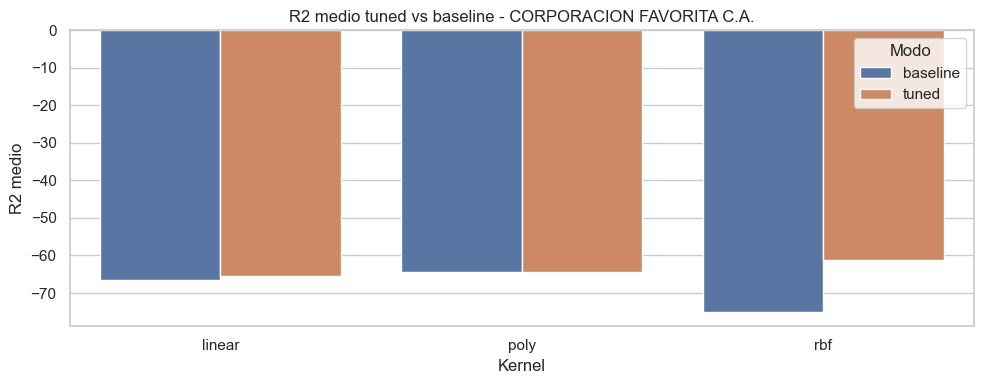

C:\Users\leynd\AppData\Local\Temp\ipykernel_26628\2493535074.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=d, x='kernel', y='r2_mean', hue='mode', ci=None)


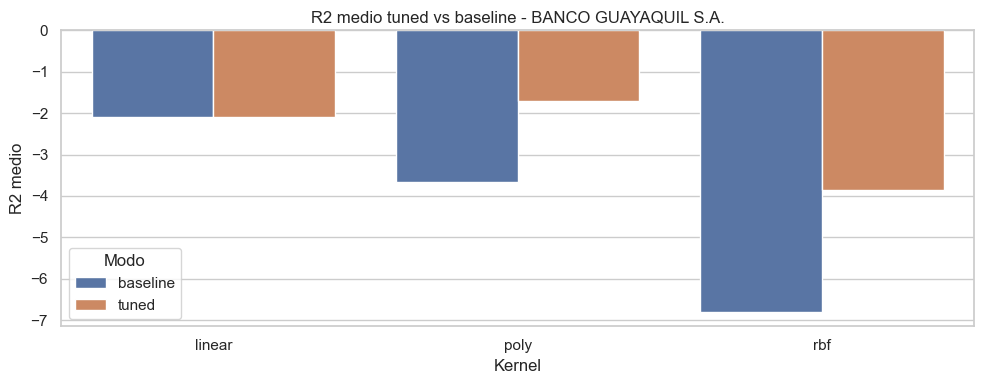

C:\Users\leynd\AppData\Local\Temp\ipykernel_26628\2493535074.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=d, x='kernel', y='r2_std', hue='pipeline', ci=None)


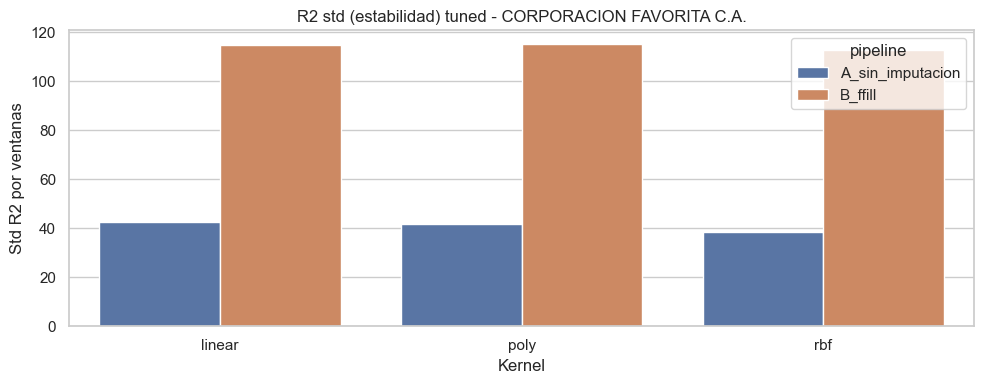

C:\Users\leynd\AppData\Local\Temp\ipykernel_26628\2493535074.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=d, x='kernel', y='r2_std', hue='pipeline', ci=None)


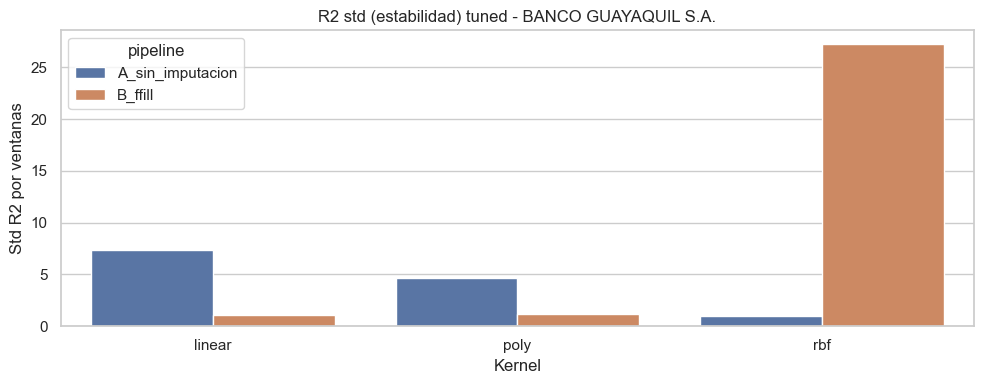

In [9]:
# R2 medio tuned vs baseline por pipeline/empresa/kernel
plot_df = summary[['pipeline', 'empresa', 'kernel', 'mode', 'r2_mean']].copy()

for empresa in empresas_objetivo:
    d = plot_df[plot_df['empresa'] == empresa].copy()
    plt.figure(figsize=(10, 4))
    sns.barplot(data=d, x='kernel', y='r2_mean', hue='mode', ci=None)
    plt.title('R2 medio tuned vs baseline - {}'.format(empresa))
    plt.xlabel('Kernel')
    plt.ylabel('R2 medio')
    plt.legend(title='Modo')
    plt.tight_layout()
    plt.show()

# Estabilidad (std de R2) tuned por pipeline
stb = summary[summary['mode'] == 'tuned'][['pipeline', 'empresa', 'kernel', 'r2_std']].copy()
for empresa in empresas_objetivo:
    d = stb[stb['empresa'] == empresa].copy()
    plt.figure(figsize=(10, 4))
    sns.barplot(data=d, x='kernel', y='r2_std', hue='pipeline', ci=None)
    plt.title('R2 std (estabilidad) tuned - {}'.format(empresa))
    plt.xlabel('Kernel')
    plt.ylabel('Std R2 por ventanas')
    plt.tight_layout()
    plt.show()

## 8) Analisis critico obligatorio y decision final
Respuestas:
1. El tuning mejora consistentemente o solo en ventanas especificas?
2. ffill mejora R2 pero reduce volatilidad?
3. Pipeline con ffill es mas estable o solo mas suave?
4. Que pipeline refleja mejor la realidad del mercado?

In [10]:
print('=== ANALISIS CRITICO FASE 5 v2 ===')

# 1) Consistencia del tuning
print('\n1) Consistencia del tuning (delta R2 tuned-baseline):')
for empresa in empresas_objetivo:
    d = delta_summary[delta_summary['empresa'] == empresa].copy()
    print('')
    print('Empresa:', empresa)
    print(d[['pipeline', 'kernel', 'delta_r2_mean', 'pct_windows_r2_improve', 'delta_mae_mean', 'delta_mse_mean']].to_string(index=False))

# 2) ffill y volatilidad
print('\n2) Efecto de ffill sobre volatilidad de retornos:')
for empresa in empresas_objetivo:
    dv = vol_df[vol_df['empresa'] == empresa].set_index('pipeline')
    std_A = dv.loc['A_sin_imputacion', 'ret_std']
    std_B = dv.loc['B_ffill', 'ret_std']
    delta_std_pct = (std_B - std_A) / std_A * 100
    print('- {}: std_A={:.6f}, std_B={:.6f}, delta={:.2f}%'.format(empresa, std_A, std_B, delta_std_pct))

# 3) Estabilidad relativa tuned entre pipelines
print('\n3) Estabilidad tuned (R2 std) por pipeline:')
stability_cmp = summary[summary['mode'] == 'tuned'].groupby(['pipeline', 'empresa'])['r2_std'].mean().reset_index()
print(stability_cmp.to_string(index=False))

# 4) Pipeline mas realista
print('\n4) Diagnostico de realismo de pipeline:')
for empresa in empresas_objetivo:
    dA = summary[(summary['empresa'] == empresa) & (summary['pipeline'] == 'A_sin_imputacion') & (summary['mode'] == 'tuned')]
    dB = summary[(summary['empresa'] == empresa) & (summary['pipeline'] == 'B_ffill') & (summary['mode'] == 'tuned')]

    bestA = dA.sort_values('r2_mean', ascending=False).iloc[0]
    bestB = dB.sort_values('r2_mean', ascending=False).iloc[0]

    print('')
    print('Empresa:', empresa)
    print('- Mejor A: kernel={}, r2_mean={:.4f}, overfit_gap_mean={:.4f}'.format(bestA['kernel'], bestA['r2_mean'], bestA['overfit_gap_mean']))
    print('- Mejor B: kernel={}, r2_mean={:.4f}, overfit_gap_mean={:.4f}'.format(bestB['kernel'], bestB['r2_mean'], bestB['overfit_gap_mean']))

print('\n=== DECISION FINAL ===')

# Regla de decision global (conservadora)
global_best = summary[summary['mode'] == 'tuned'].sort_values('r2_mean', ascending=False).iloc[0]

if global_best['r2_mean'] > 0:
    tuning_decision = 'SI, vale la pena explorar tuning adicional (senal minima detectada).'
else:
    tuning_decision = 'NO por ahora: tuning no logra sacar R2 positivo de forma robusta.'

# Decision ffill basada en suavizado + realismo
ffill_std_effect = []
for empresa in empresas_objetivo:
    dv = vol_df[vol_df['empresa'] == empresa].set_index('pipeline')
    delta_std_pct = (dv.loc['B_ffill', 'ret_std'] - dv.loc['A_sin_imputacion', 'ret_std']) / dv.loc['A_sin_imputacion', 'ret_std'] * 100
    ffill_std_effect.append(delta_std_pct)

if np.mean(ffill_std_effect) < -5:
    ffill_decision = 'Descartar como pipeline final principal: ffill suaviza la dinamica y puede introducir mejora artificial.'
else:
    ffill_decision = 'Usar solo como sensibilidad/robustez, no como pipeline principal por defecto.'

print('- ¿Vale la pena usar tuning en este problema?: {}'.format(tuning_decision))
print('- ¿ffill debe considerarse en pipeline final?: {}'.format(ffill_decision))
print('- Pipeline recomendado para reflejar realidad de mercado: A_sin_imputacion (event-time).')

=== ANALISIS CRITICO FASE 5 v2 ===

1) Consistencia del tuning (delta R2 tuned-baseline):

Empresa: CORPORACION FAVORITA C.A.
        pipeline kernel  delta_r2_mean  pct_windows_r2_improve  delta_mae_mean  delta_mse_mean
A_sin_imputacion linear       0.036441               26.086957       -0.000033       -0.000003
A_sin_imputacion   poly       2.941008               43.478261       -0.003710       -0.004583
A_sin_imputacion    rbf      11.366709               60.869565       -0.007498       -0.000662
         B_ffill linear       2.252594               28.571429       -0.000655       -0.000032
         B_ffill   poly      -2.856088               24.675325        0.002911       -0.000078
         B_ffill    rbf      16.371738               53.246753       -0.005275       -0.000455

Empresa: BANCO GUAYAQUIL S.A.
        pipeline kernel  delta_r2_mean  pct_windows_r2_improve  delta_mae_mean  delta_mse_mean
A_sin_imputacion linear       0.006945               32.142857       -0.000005   -5